### 1.4.8.2. Homogeneous Systems: The Eigenvalue Method

$$
\mathbf{X} = \mathbf{K}e^{\lambda t} \;\Rightarrow\; (A - \lambda I)\mathbf{K} = \mathbf{0},
\quad \det(A - \lambda I) = 0,
\quad \mathbf{X} = c_1\mathbf{K}_1 e^{\lambda_1 t} + \cdots + c_n\mathbf{K}_n e^{\lambda_n t}.
$$

**Explanation:**

Seeking solutions of $\mathbf{X}' = A\mathbf{X}$ of the form $\mathbf{K}e^{\lambda t}$ turns the system into the [eigenvalue](../../01_Linear_Algebra/07_Theoretical_Linear_Algebra/08_eigenvalue.ipynb) problem $(A - \lambda I)\mathbf{K} = \mathbf{0}$: the **eigenvalues** of $A$ (roots of $\det(A - \lambda I) = 0$) set the exponential rates, and their [eigenvectors](../../01_Linear_Algebra/07_Theoretical_Linear_Algebra/09_eigenvector.ipynb) set the directions. For $n$ distinct real eigenvalues the general solution is the combination above. The signs of the eigenvalues classify the equilibrium at the origin — an **attractor** if all negative, a **repeller** if all positive, a **saddle** if of mixed sign — which is exactly the linear stability analysis used throughout control.

**Intuition:**

Trajectories align with the eigenvector directions; opposite-sign eigenvalues give a saddle at the origin.

<p align="center">
  <img src="../../../Figures/01040802_phase_portrait_saddle.jpeg"
       alt="Phase portrait of a saddle: trajectories along the two eigenvector lines"
       width="300">
</p>

**Numerical Example:**

Solve $x' = 2x + 3y$, $y' = 2x + y$, i.e. $\mathbf{X}' = \begin{pmatrix} 2 & 3 \\ 2 & 1 \end{pmatrix}\mathbf{X}$.

**Eigenvalues.**

$$
\det(A - \lambda I) = \begin{vmatrix} 2-\lambda & 3 \\ 2 & 1-\lambda \end{vmatrix} = \lambda^2 - 3\lambda - 4 = (\lambda+1)(\lambda-4) = 0 \;\Rightarrow\; \lambda_1 = -1,\ \lambda_2 = 4 .
$$

**Eigenvectors.** For $\lambda_1 = -1$: $(A + I)\mathbf{K} = 0$ gives $3k_1 + 3k_2 = 0$, so $k_1 = -k_2$ and $\mathbf{K}_1 = \begin{pmatrix} 1 \\ -1 \end{pmatrix}$. For $\lambda_2 = 4$: $-2k_1 + 3k_2 = 0$, so $k_1 = \tfrac32 k_2$ and $\mathbf{K}_2 = \begin{pmatrix} 3 \\ 2 \end{pmatrix}$.

**General solution.**

$$
\mathbf{X} = c_1\begin{pmatrix} 1 \\ -1 \end{pmatrix}e^{-t} + c_2\begin{pmatrix} 3 \\ 2 \end{pmatrix}e^{4t} .
$$

The eigenvalues have opposite signs, so the origin is a **saddle point** — trajectories approach along $\mathbf{K}_1$ (decaying $e^{-t}$) and depart along $\mathbf{K}_2$ (growing $e^{4t}$).

In [1]:
import sympy as sp

t = sp.symbols("t")
A = sp.Matrix([[2, 3], [2, 1]])

eigen_data = A.eigenvects()
print("det(A - λI) =", sp.factor(A.charpoly(sp.Symbol("lam")).as_expr()))
for eigenvalue, multiplicity, vectors in eigen_data:
    print(f"λ = {eigenvalue}, eigenvector = {list(vectors[0])}")
print("origin is a saddle (eigenvalues of opposite sign)")

det(A - λI) = (lam - 4)*(lam + 1)
λ = -1, eigenvector = [-1, 1]
λ = 4, eigenvector = [3/2, 1]
origin is a saddle (eigenvalues of opposite sign)


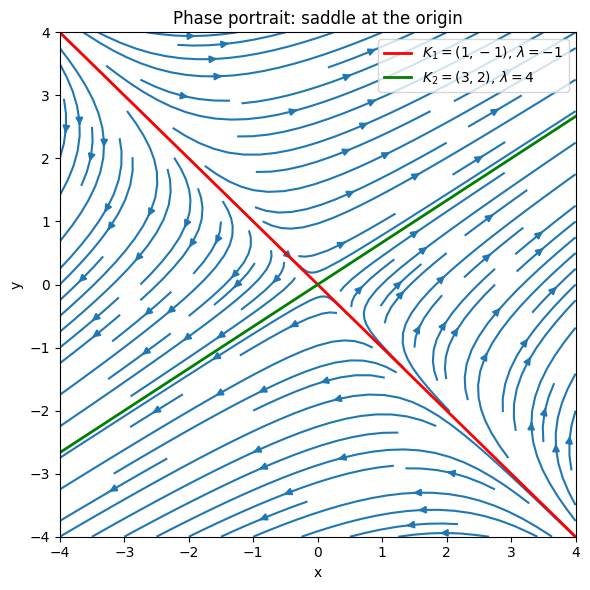

In [2]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-4, 4, 21)
mesh_x, mesh_y = np.meshgrid(grid, grid)
velocity_x = 2 * mesh_x + 3 * mesh_y
velocity_y = 2 * mesh_x + mesh_y

plt.figure(figsize=(6, 6))
plt.streamplot(mesh_x, mesh_y, velocity_x, velocity_y, density=1.1, color="C0")
line = np.linspace(-4, 4, 10)
plt.plot(line, -line, "r", linewidth=2, label=r"$K_1=(1,-1)$, $\lambda=-1$")
plt.plot(3 * line / 2, line, "g", linewidth=2, label=r"$K_2=(3,2)$, $\lambda=4$")
plt.xlim(-4, 4); plt.ylim(-4, 4); plt.xlabel("x"); plt.ylabel("y")
plt.title("Phase portrait: saddle at the origin"); plt.legend(); plt.tight_layout()
plt.show()

**References:**

[📘 Zill, D. G. (2016). *A First Course in Differential Equations with Modeling Applications* (11th ed.). Cengage Learning.](https://www.cengage.com/c/a-first-course-in-differential-equations-with-modeling-applications-11e-zill/9781305965720/)

---

[⬅️ Previous: Linear Systems in Matrix Form](./01_linear_systems_in_matrix_form.ipynb) | [Next: Repeated and Complex Eigenvalues ➡️](./03_repeated_and_complex_eigenvalues.ipynb)